# SSNE | Lab 4 | Regularyzacje / przeuczenie / tips & tricks

## Prerequisites

In [ ]:
!pip install torchvision seaborn tqdm

In [1]:
import torch, torchvision
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
import torch.functional as F
import numpy as np
import pandas as pd
import torch.utils.data as data
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random
from tqdm import tqdm

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)  # multi-GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # wymagane przez niektóre operacje CUDA

## Trick #1 - Batch Normalization // BatchNorm
Batch-Normalization is an algorithmic method which makes the training of Deep Neural Networks (DNN) faster and more stable. 

In [3]:
# data.csv from Mini-Projekt 1

train_data = pd.read_csv("https://drive.google.com/uc?export=download&id=19lok0wZOqUThdF8wv_hnVIaIQ-VRD0RV",index_col=0)
train = train_data.drop(columns=["casual","registered","cnt","dteday","season","yr","mnth"])
train_dataset = data.TensorDataset(torch.from_numpy(train.values).float(),torch.from_numpy(train_data.values[:,-1].astype(float)).float())
data_loader  = data.DataLoader(train_dataset, batch_size=256, shuffle=True)

In [4]:
class MyNet(nn.Module):
    def __init__(self):
        super(MyNet, self).__init__()
        self.lin1 =nn.Linear(9, 48)
        self.act1 =nn.ReLU()
        self.lin2 =nn.Linear(48, 24)
        self.act2 =nn.ReLU()
        self.lin3 =nn.Linear(24, 1)


    def forward(self, x):
        x = self.lin1(x)
        x = self.act1(x)
        x = self.lin2(x)
        x = self.act2(x)
        x = self.lin3(x)
        return x

In [5]:
class MyNetBN(nn.Module):
    def __init__(self):
        super(MyNetBN, self).__init__()
        self.lin1 =nn.Linear(9, 48)  # 28 x 28 = 784
        self.bn1 = nn.BatchNorm1d(48)
        self.act1 =nn.ReLU()
        self.lin2 =nn.Linear(48, 24)
        self.bn2 = nn.BatchNorm1d(24)
        self.act2 =nn.ReLU()
        self.lin3 =nn.Linear(24, 1)


    def forward(self, x):
        x = self.lin1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.lin2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.lin3(x)
        return x

In [6]:
model = MyNet()
print(model)
model_bn = MyNetBN()
print(model_bn)

MyNet(
  (lin1): Linear(in_features=9, out_features=48, bias=True)
  (act1): ReLU()
  (lin2): Linear(in_features=48, out_features=24, bias=True)
  (act2): ReLU()
  (lin3): Linear(in_features=24, out_features=1, bias=True)
)
MyNetBN(
  (lin1): Linear(in_features=9, out_features=48, bias=True)
  (bn1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU()
  (lin2): Linear(in_features=48, out_features=24, bias=True)
  (bn2): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act2): ReLU()
  (lin3): Linear(in_features=24, out_features=1, bias=True)
)


In [7]:
loss_fn = nn.MSELoss()
opt = optim.SGD(model.parameters(), lr=0.0001, momentum=0.5)
opt_bn = optim.SGD(model_bn.parameters(), lr=0.0001, momentum=0.5)

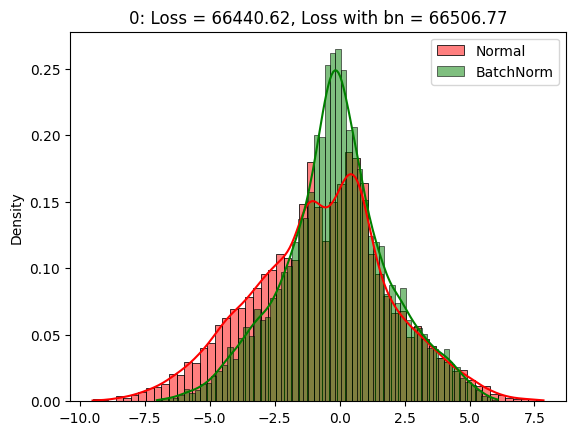

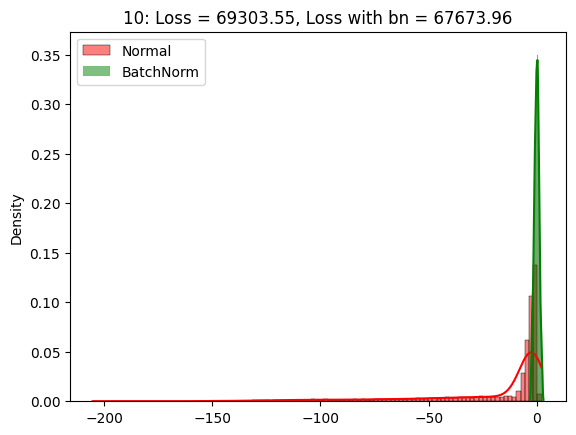

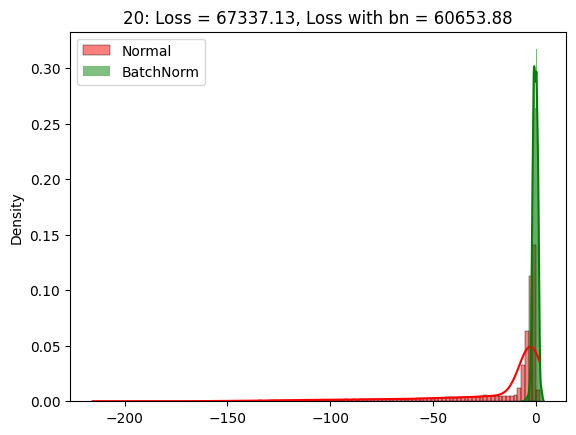

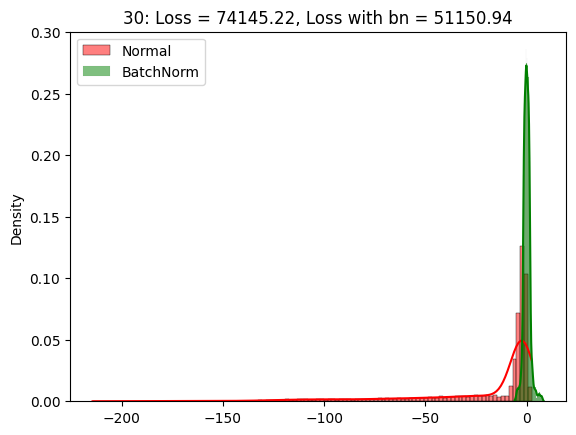

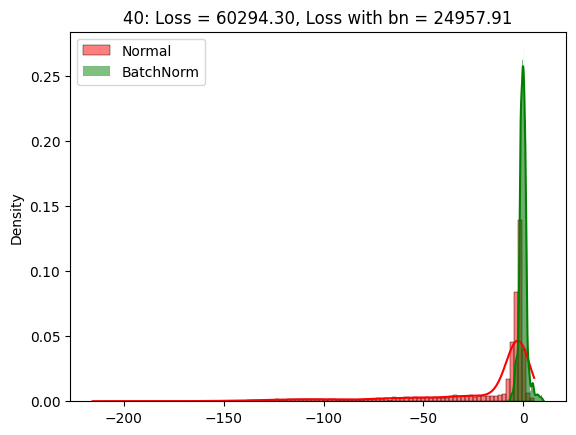

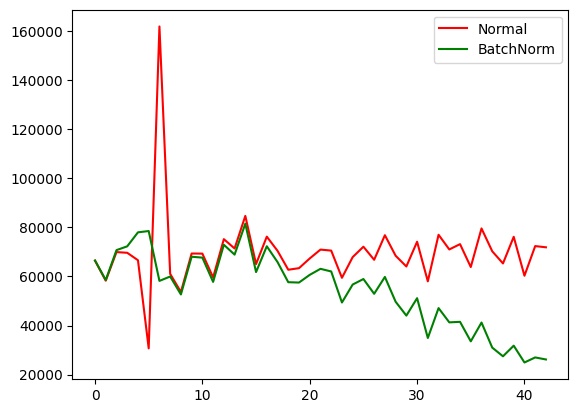

----------------------


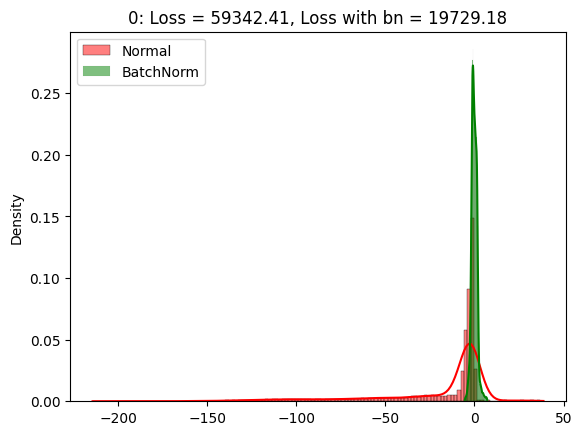

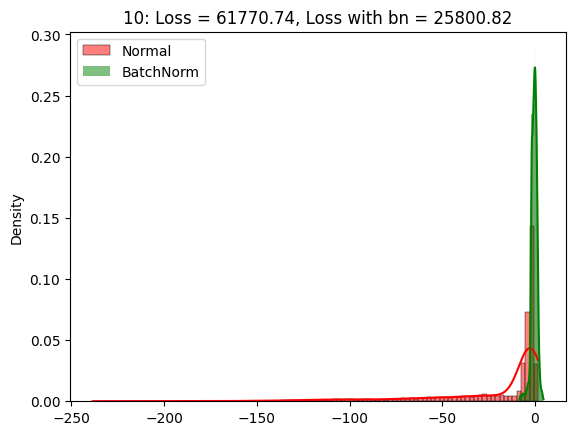

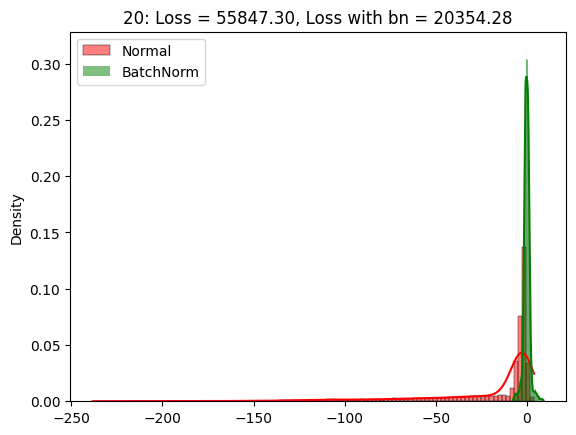

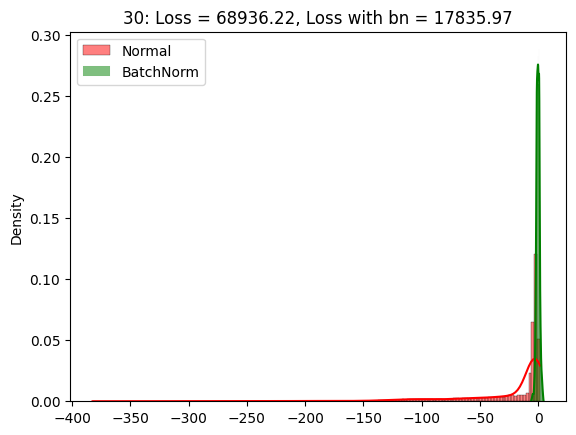

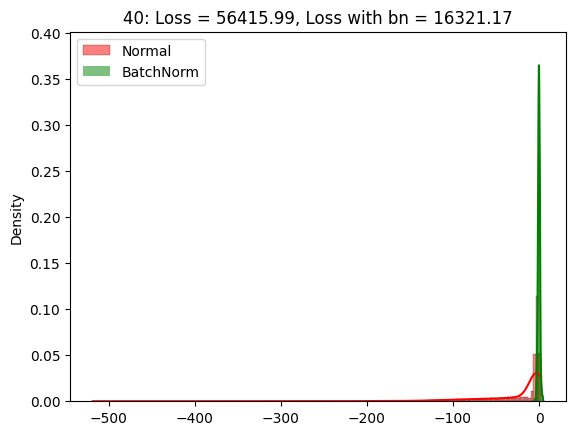

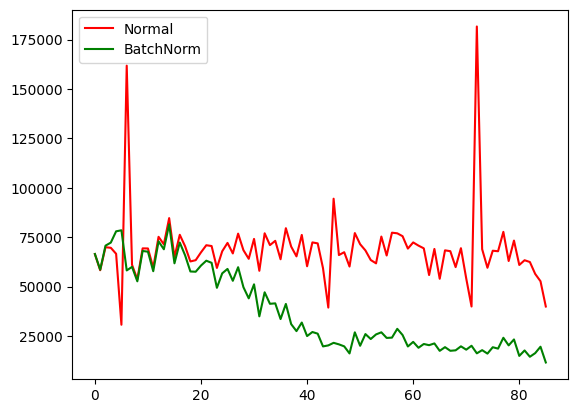

----------------------


In [8]:
loss_arr = []
loss_bn_arr = []
max_epochs = 2

for epoch in range(max_epochs):
    for i, batch in enumerate(data_loader, 0):

        inputs, labels = batch

        # training steps for normal model
        opt.zero_grad()
        outputs = model(inputs).squeeze()
        loss = loss_fn(outputs, labels)
        loss.backward()
        opt.step()

        # training steps for bn model
        opt_bn.zero_grad()
        outputs_bn = model_bn(inputs).squeeze()
        loss_bn = loss_fn(outputs_bn, labels)
        loss_bn.backward()
        opt_bn.step()

        loss_arr.append(loss.item())
        loss_bn_arr.append(loss_bn.item())

        if i % 10 == 0:

            inputs = inputs.view(inputs.size(0), -1)

            model.eval()
            model_bn.eval()

            a = model.lin1(inputs)
            a = a.detach().numpy().ravel()
            sns.histplot(a, kde=True, color='r', label='Normal', stat="density")

            b = model_bn.lin1(inputs)
            b = model_bn.bn1(b)
            b = b.detach().numpy().ravel()

            sns.histplot(b, kde=True, color='g', label='BatchNorm', stat="density")
            plt.title('%d: Loss = %0.2f, Loss with bn = %0.2f' % (i, loss.item(), loss_bn.item()))
            plt.legend()
            plt.show()
            plt.pause(0.5)

            model.train()
            model_bn.train()



    plt.plot(loss_arr, 'r', label='Normal')
    plt.plot(loss_bn_arr, 'g', label='BatchNorm')
    plt.legend()
    plt.show()
    print('----------------------')

Visualisation from AI by Hand [here](https://www.byhand.ai/p/batch-normalization-by-hand).

In [9]:
print(f"{model_bn.lin1=}")
print(f"{model_bn.bn1=}")
print(f"-----------------")
print(f"Running mean: {model_bn.bn1.running_mean.data}")
print(f"Running std: {model_bn.bn1.running_var.data}")
print(f"-----------------")
print(f"Scale: {model_bn.bn1.weight.data}")
print(f"Shift: {model_bn.bn1.bias.data}")


model_bn.lin1=Linear(in_features=9, out_features=48, bias=True)
model_bn.bn1=BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
-----------------
Running mean: tensor([ -1.1801,  -2.7009,  -2.9282,  -1.0190,  19.7018,  -2.4084, -10.5718,
         -3.4986,  -3.9609,  -5.2655, -27.7376,   1.5925,   5.2486,  -5.1844,
         38.5735,   4.5549,  -2.6836,  22.1399,  -2.6003,  -3.7974,  -4.8574,
         -2.5258,  -3.7014,   2.4738,  -4.5611,  -4.6698,   9.3495, -11.2409,
         -3.1127,   8.5429,   8.5971,  30.3859,  -3.2220,  -1.8130,  -2.0000,
          9.5676,  -5.7011,  26.7413,   6.2537,  10.4663,  -4.2485,   8.8283,
         -4.5776,   6.8065,  -7.0828,  -9.5817,   0.6422,  -3.5458])
Running std: tensor([3.3220e+00, 2.7837e+00, 4.7826e+00, 1.1989e+00, 1.3324e+02, 3.2824e+00,
        5.0423e+01, 6.1600e+00, 6.7982e+00, 1.0859e+01, 3.0276e+02, 2.6068e+00,
        1.9047e+01, 1.7196e+01, 8.2930e+02, 8.5718e+00, 2.1695e+00, 1.9491e+02,
        2.6812e+00, 4

1. During training:
- Inputs?
- Running mean and std?
- Scale and shift?

2. During evaluation:
- Inputs?
- Running mean and std?
- Scale and shift?


![](https://forums.fast.ai/uploads/default/original/2X/9/998a1be6463260f731481106756034c42040e256.jpg)

## Przeuczanie sieci

In [10]:
mnist_data = torchvision.datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())
mnist_data = list(mnist_data)
mnist_train = mnist_data[:20]
mnist_val   = mnist_data[20:1000]

100%|██████████| 9.91M/9.91M [00:17<00:00, 565kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 145kB/s]
100%|██████████| 1.65M/1.65M [00:10<00:00, 165kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.07MB/s]


In [11]:
mnist_train[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [20]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# device = torch.device("cuda")
device = torch.device("cpu")

In [21]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        self.layer1 = nn.Linear(28 * 28, 800)
        self.act_1 =  nn.Tanh()
        self.layer2 = nn.Linear(800, 800)
        self.act_2 = nn.Tanh()
        self.layer3 = nn.Linear(800, 10)
    def forward(self, img):
        flattened = img.view(-1, 28 * 28)
        activation1 = self.act_1(self.layer1(flattened))
        activation2 = self.act_2(self.layer2(activation1))
        output = self.layer3(activation2)
        return output

In [22]:
def train(model, train, valid, batch_size=10, num_epochs=1, learn_rate=0.001, weight_decay=0, with_plot=False):
    train_loader = torch.utils.data.DataLoader(train,
                                               batch_size=batch_size,
                                               shuffle=True) # shuffle after every epoch
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learn_rate,momentum=0.9, weight_decay=weight_decay)

    iters, losses, train_acc, val_acc = [], [], [], []

    # training
#     n = 0 # the number of iterations
    idx = 0
    for n in range(num_epochs):
        for imgs, labels in iter(train_loader):
            imgs, labels = imgs.to(device), labels.to(device)
            model.train()
            out = model(imgs)             # forward pass
            loss = criterion(out, labels) # compute the total loss
            loss.backward()               # backward pass (compute parameter updates)
            optimizer.step()              # make the updates for each parameter
            optimizer.zero_grad()

            # save the current training information
            if idx % 10 == 9:
                iters.append(idx)
                losses.append(float(loss)/batch_size)        # compute *average* loss
                train_acc.append(get_accuracy(model, train)) # compute training accuracy
                val_acc.append(get_accuracy(model, valid))   # compute validation accuracy
            idx+=1
        if n%100==0:
            print(f"Epoch {n}, loss: {loss.item()}")


    if with_plot:
        # plotting
        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        plt.title("Training Curve")
        plt.plot(iters, losses, label="Train")
        plt.xlabel("Iterations")
        plt.ylabel("Loss")

        plt.subplot(1,2,2)
        plt.title("Training Curve")
        plt.plot(iters, train_acc, label="Train")
        plt.plot(iters, val_acc, label="Validation")
        plt.xlabel("Iterations")
        plt.ylabel("Training Accuracy")
        plt.legend(loc='best')
        plt.show()


    print("Final Training Accuracy: {}".format(train_acc[-1]))
    print("Final Validation Accuracy: {}".format(val_acc[-1]))


train_acc_loader = torch.utils.data.DataLoader(mnist_train, batch_size=100)
val_acc_loader = torch.utils.data.DataLoader(mnist_val, batch_size=1000)

def get_accuracy(model, data):
    correct = 0
    total = 0
    model.eval() #*********#
    for imgs, labels in torch.utils.data.DataLoader(data, batch_size=64):
        imgs, labels = imgs.to(device), labels.to(device)
        output = model(imgs)
        pred = output.max(1, keepdim=True)[1] # get the index of the max logit
        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += imgs.shape[0]
    return correct / total

Epoch 0, loss: 2.2941441535949707
Epoch 100, loss: 0.5520029067993164
Epoch 200, loss: 0.10244069993495941
Epoch 300, loss: 0.05089163780212402
Epoch 400, loss: 0.026985177770256996
Epoch 500, loss: 0.020747194066643715
Epoch 600, loss: 0.013810360804200172
Epoch 700, loss: 0.014680502936244011
Epoch 800, loss: 0.01036924310028553
Epoch 900, loss: 0.006675140466541052


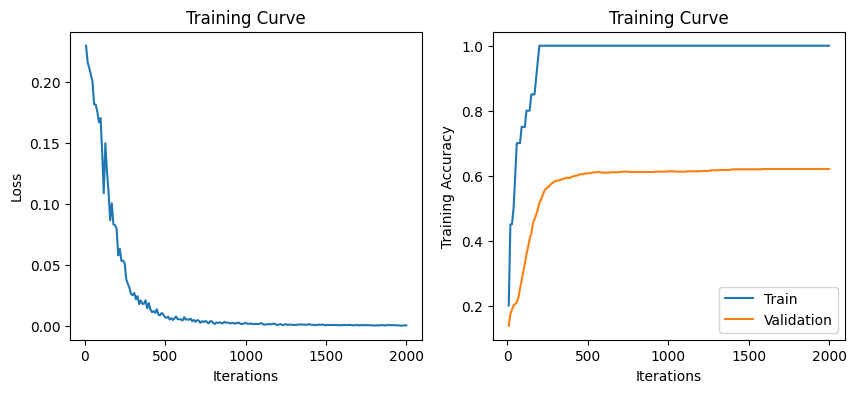

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.6204081632653061


In [24]:
model = MNISTClassifier().to(device)
train(model, mnist_train, mnist_val, num_epochs=1000, with_plot=True) # with_plot=True

## Trick #2 - Dropout
Maskowanie losowych neuronów w sieci.
Dropout inaczej się w train() i eval().

+ Dropout oryginalnie: [Dropout: A Simple Way to Prevent Neural Networks from Overfitting](https://jmlr.org/papers/v15/srivastava14a.html)

![obrazek](https://miro.medium.com/1*o9j9haCPmXfTBK-qrUJbsQ.png)

+ Dropout w [PyTorchu](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html)

W pytorchu dropuout dziala inaczej - wymnaza juz w terningu zeby w czasiw ewaluacji nic nie robic

In [ ]:
m = nn.Dropout(p=0.5)
x = torch.randn((1, 6))

m.train()
print(f"x:     {x}")
print(f"train: {m(x)}")         # 1 / (1 - 0.5) = 2

m.eval()
print(f"eval:  {m(x)}")

x:     tensor([[-0.1006,  0.0824, -1.7545, -0.8445, -0.6222, -1.4087]])
train: tensor([[-0.0000,  0.0000, -3.5090, -0.0000, -0.0000, -2.8174]])
eval:  tensor([[-0.1006,  0.0824, -1.7545, -0.8445, -0.6222, -1.4087]])


In [27]:
class MNISTClassifier_Dropout(nn.Module):
    def __init__(self):
        super(MNISTClassifier_Dropout, self).__init__()
        self.layer1 = nn.Linear(28 * 28, 800)
        self.act_1 =  nn.Tanh()
        self.d1 = nn.Dropout(0.8)

        self.layer2 = nn.Linear(800, 800)
        self.act_2 = nn.Tanh()
        self.d2 = nn.Dropout(0.8)

        self.layer3 = nn.Linear(800, 10)
    def forward(self, img):
        flattened = img.view(-1, 28 * 28)
        activation1 = self.act_1(self.layer1(flattened))
        x = self.d1(activation1)
        activation2 = self.act_2(self.layer2(x))
        x = self.d2(activation2)
        output = self.layer3(x)
        return output

Epoch 0, loss: 2.302685499191284
Epoch 100, loss: 0.8470114469528198
Epoch 200, loss: 0.11981166899204254
Epoch 300, loss: 0.08152414858341217
Epoch 400, loss: 0.04139483720064163
Epoch 500, loss: 0.04425657168030739
Epoch 600, loss: 0.023127565160393715
Epoch 700, loss: 0.006304743234068155
Epoch 800, loss: 0.03156828507781029
Epoch 900, loss: 0.009193174540996552


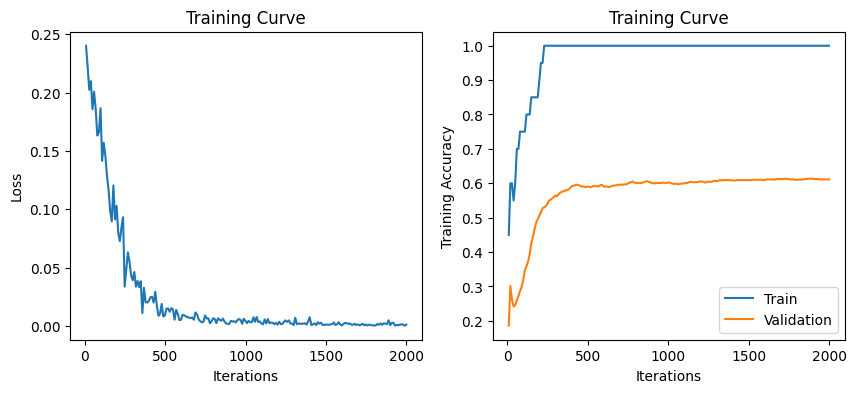

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.6112244897959184


In [28]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

model = MNISTClassifier_Dropout().to(device)
train(model, mnist_train, mnist_val, num_epochs=1000, with_plot=True)

## Trick #3 - regularyzacja wag

### L1 vs L2 Regularization

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*Tyu8vrwWsm0qJ4BhrSdAFA.png)



W torch: domyślnie L2 jako `weight_decay`

Epoch 0, loss: 2.3026845455169678
Epoch 100, loss: 0.8822253942489624
Epoch 200, loss: 0.13872556388378143
Epoch 300, loss: 0.10406637191772461
Epoch 400, loss: 0.05723368376493454
Epoch 500, loss: 0.06893299520015717
Epoch 600, loss: 0.03997452184557915
Epoch 700, loss: 0.013030353002250195
Epoch 800, loss: 0.05836547538638115
Epoch 900, loss: 0.023470886051654816


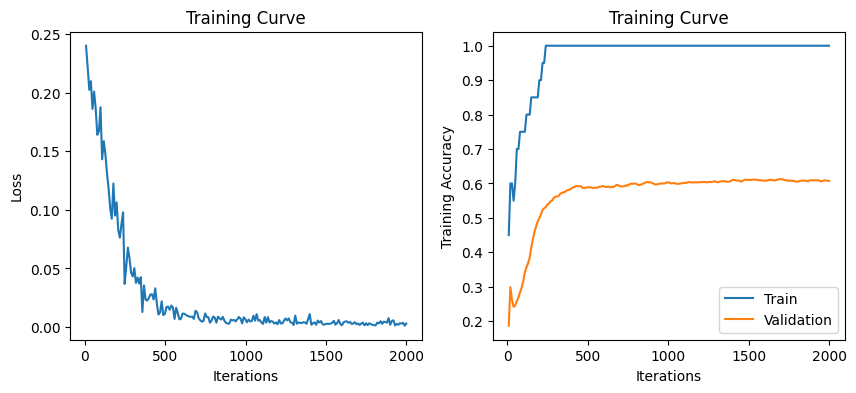

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.6071428571428571


In [29]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

model = MNISTClassifier_Dropout().to(device)
train(model, mnist_train, mnist_val, num_epochs=1000, weight_decay=1e-2, with_plot=True)

### Zadanie - własna regularyzacja

In [30]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        self.layer1 = nn.Linear(28 * 28, 800)
        self.act_1 =  nn.Tanh()
        self.layer2 = nn.Linear(800, 800)
        self.act_2 = nn.Tanh()
        self.layer3 = nn.Linear(800, 10)
    def forward(self, img):
        flattened = img.view(-1, 28 * 28)
        activation1 = self.act_1(self.layer1(flattened))
        activation2 = self.act_2(self.layer2(activation1))
        output = self.layer3(activation2)
        return output

Epoch 0
Epoch 100
Epoch 200
Epoch 300
Epoch 400
Epoch 500
Epoch 600
Epoch 700
Epoch 800
Epoch 900


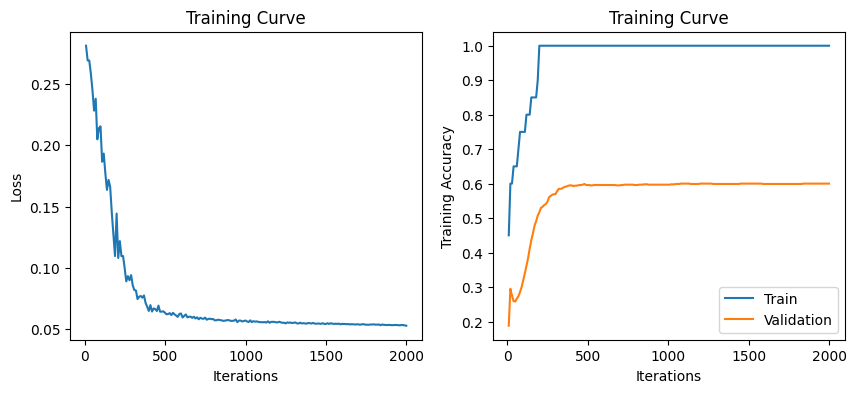

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.6


In [61]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

# model / optimizer
model = MNISTClassifier().to(device)
train_loader = torch.utils.data.DataLoader(mnist_train, batch_size=10, shuffle=True) # shuffle after every epoch
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

iters, losses, train_acc, val_acc = [], [], [], []

### TODO:
REGULARIZATION_LAMBDA = 1e-3
###

idx = 0
for n in range(1000):
    for imgs, labels in iter(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)
        model.train()
        out = model(imgs)
        ### TODO:
        # Here propose some form of regularization
        # HINT: check list(model.named_parameters())

        
        sum=0
        for name, val in list(model.named_parameters()):
            if '.weight' in name:
                sum += torch.sum(torch.square(val))
                # sum += torch.sum(torch.abs(val))
        
        regularization = (
            sum
            * REGULARIZATION_LAMBDA
        )
        # print(sum)
        loss = criterion(out, labels) + regularization
        ###
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if idx % 10 == 9:
            iters.append(idx)
            losses.append(float(loss)/10)        # compute *average* loss
            train_acc.append(get_accuracy(model, mnist_train)) # compute training accuracy
            val_acc.append(get_accuracy(model, mnist_val))   # compute validation accuracy
        idx+=1
    if n%100==0:
        print(f"Epoch {n}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Training Curve")
plt.plot(iters, losses, label="Train")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.title("Training Curve")
plt.plot(iters, train_acc, label="Train")
plt.plot(iters, val_acc, label="Validation")
plt.xlabel("Iterations")
plt.ylabel("Training Accuracy")
plt.legend(loc='best')
plt.show()


print("Final Training Accuracy: {}".format(train_acc[-1]))
print("Final Validation Accuracy: {}".format(val_acc[-1]))

## Wielkość sieci a jej jakość

In [62]:
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

In [63]:
class MNISTClassifier_parametrized(nn.Module):
    def __init__(self,size_1,size_2):
        super(MNISTClassifier_parametrized, self).__init__()
        self.layer1 = nn.Linear(28 * 28, size_1)
        self.act_1 =  nn.Tanh()
        self.layer2 = nn.Linear(size_1, size_2)
        self.act_2 = nn.Tanh()
        self.layer3 = nn.Linear(size_2, 10)
    def forward(self, img):
        flattened = img.view(-1, 28 * 28)
        activation1 = self.act_1(self.layer1(flattened))
        activation2 = self.act_2(self.layer2(activation1))
        output = self.layer3(activation2)
        return output

In [64]:
set_seed(42)
model = MNISTClassifier_parametrized(5000,3000).to(device)
train(model, mnist_train, mnist_val, num_epochs=1000, with_plot=True)

Epoch 0, loss: 2.32747220993042
Epoch 100, loss: 0.18253165483474731
Epoch 200, loss: 0.0437723770737648


KeyboardInterrupt: 

In [ ]:
set_seed(42)
model = MNISTClassifier_parametrized(2000,1000).to(device)
train(model, mnist_train, mnist_val, num_epochs=1000, with_plot=True)

In [ ]:
set_seed(42)
model = MNISTClassifier_parametrized(1000,100).to(device)
train(model, mnist_train, mnist_val, num_epochs=1000, with_plot=True)

In [ ]:
set_seed(42)
model = MNISTClassifier_parametrized(20,10).to(device)
train(model, mnist_train, mnist_val, num_epochs=1000, with_plot=True)

In [ ]:
set_seed(42)
model = MNISTClassifier_parametrized(20,10).to(device)
train(model, mnist_train, mnist_val, num_epochs=5000, with_plot=True)

## Architecture search

In [65]:
def fast_accuracy(model, data):
    with torch.no_grad():
        correct = 0
        total = 0
        model.eval()
        imgs, labels = data
        output = model(imgs.to(device))
        pred = output.max(1, keepdim=True)[1]
        correct += pred.eq(labels.view_as(pred).to(device)).sum().item()
        total += imgs.shape[0]
    return correct / total

def train_search(model, train, valid, batch_size=10, num_epochs=1, learn_rate=0.001, weight_decay=0):
    train_loader = torch.utils.data.DataLoader(train,
                                               batch_size=batch_size,
                                               shuffle=True) # shuffle after every epoch
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learn_rate,momentum=0.9, weight_decay=weight_decay)

    iters, losses, train_acc, val_acc = [], [], [], []

    idx = 0
    for n in range(num_epochs):
        for imgs, labels in iter(train_loader):
            imgs, labels = imgs.to(device), labels.to(device)
            model.train()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

    return(fast_accuracy(model, valid))

In [66]:
mnist_val_preprocessed = torch.cat([batch[0] for batch in mnist_val]), torch.tensor([batch[1] for batch in mnist_val])

In [67]:
mnist_data = torchvision.datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())
mnist_data = list(mnist_data)
mnist_train = mnist_data[:20]
mnist_val   = mnist_data[20:10000]

In [68]:
# first_layer = [2000, 1000, 500, 100, 50, 10]
# second_layer = [5000, 2000, 1000, 500, 100, 50, 10]

# # mniej parametrow
first_layer = [50, 10]
second_layer = [50, 10]

results = []
for i in range(len(first_layer)):
    for j in range(len(second_layer)):
        set_seed(42)
        model = MNISTClassifier_parametrized(first_layer[i],second_layer[j]).to(device)
        val_acc = train_search(model, mnist_train, mnist_val_preprocessed, num_epochs=1000)
        print(first_layer[i],second_layer[j],val_acc)
        results.append({"first": first_layer[i], "second": second_layer[j],"acc":val_acc})
results = pd.DataFrame(results)

50 50 0.5785714285714286
50 10 0.4969387755102041
10 50 0.5663265306122449
10 10 0.5112244897959184


In [ ]:
results.to_csv("params_search.csv",index=False)
results = pd.read_csv("params_search.csv")

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
ax.scatter(results["first"], results["second"], c=np.exp(results.acc*100), cmap="YlGn", s=1000)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("First layer")
plt.ylabel("Second layer")
for idx, row in results.iterrows():
    ax.annotate(str(row.acc)[:5], (row["first"]*0.82, row["second"]))
plt.show()

### Sieć o większej liczbie warstw wymaga dłuższego treningu

In [69]:
class MNISTClassifier_parametrized_3(nn.Module):
    def __init__(self,sizes):
        super(MNISTClassifier_parametrized_3, self).__init__()
        size_in = 28 * 28

        layers = []
        for size in sizes:
            layers.append(nn.Linear(size_in, size))
            layers.append(nn.Tanh())
            size_in = size
        layers.append(nn.Linear(size_in, 10))
        self.layers = nn.Sequential(*layers)

    def forward(self, img):
        flattened = img.view(-1, 28 * 28)
        
        output = self.layers(flattened)
        return output

Epoch 0, loss: 2.2955985069274902


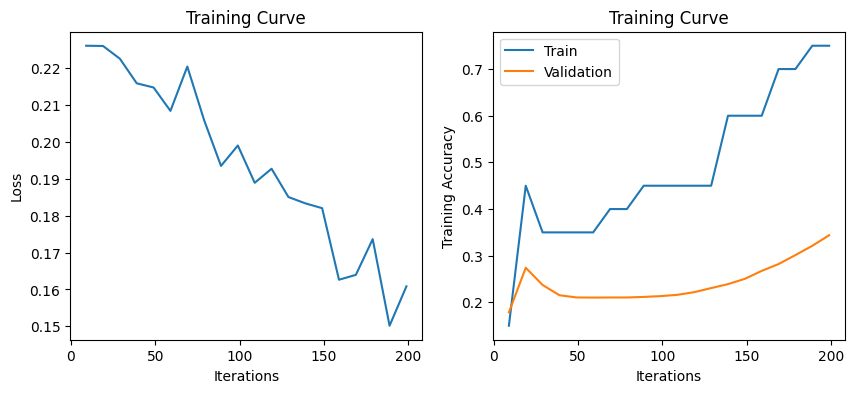

Final Training Accuracy: 0.75
Final Validation Accuracy: 0.3438877755511022


In [70]:
set_seed(42)
model = MNISTClassifier_parametrized_3([1000,500,100]).to(device)
train(model, mnist_train, mnist_val, num_epochs=100, with_plot=True)

Epoch 0, loss: 2.2922756671905518


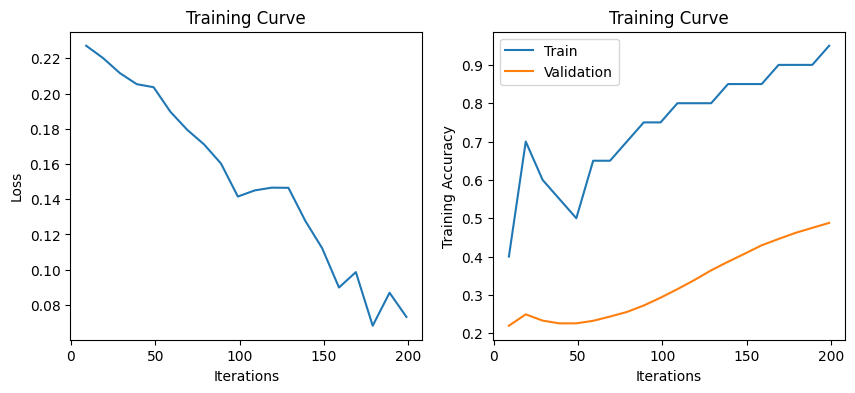

Final Training Accuracy: 0.95
Final Validation Accuracy: 0.4877755511022044


In [71]:
set_seed(42)
model = MNISTClassifier_parametrized_3([1000, 500]).to(device)
train(model, mnist_train, mnist_val, num_epochs=100, with_plot=True)

### Większa liczba warstw może prowadzić do przeuczania

Epoch 0, loss: 2.2955985069274902
Epoch 100, loss: 1.4384114742279053
Epoch 200, loss: 0.45347529649734497
Epoch 300, loss: 0.15286780893802643
Epoch 400, loss: 0.08510486781597137
Epoch 500, loss: 0.04410172626376152
Epoch 600, loss: 0.021440992131829262
Epoch 700, loss: 0.020208479836583138
Epoch 800, loss: 0.014600120484828949
Epoch 900, loss: 0.014825520105659962
Epoch 1000, loss: 0.012730489484965801
Epoch 1100, loss: 0.013835364952683449
Epoch 1200, loss: 0.009723221883177757
Epoch 1300, loss: 0.006551964674144983
Epoch 1400, loss: 0.007402009330689907
Epoch 1500, loss: 0.004688661079853773
Epoch 1600, loss: 0.007544979453086853
Epoch 1700, loss: 0.005247766617685556
Epoch 1800, loss: 0.005166688933968544
Epoch 1900, loss: 0.003824611660093069


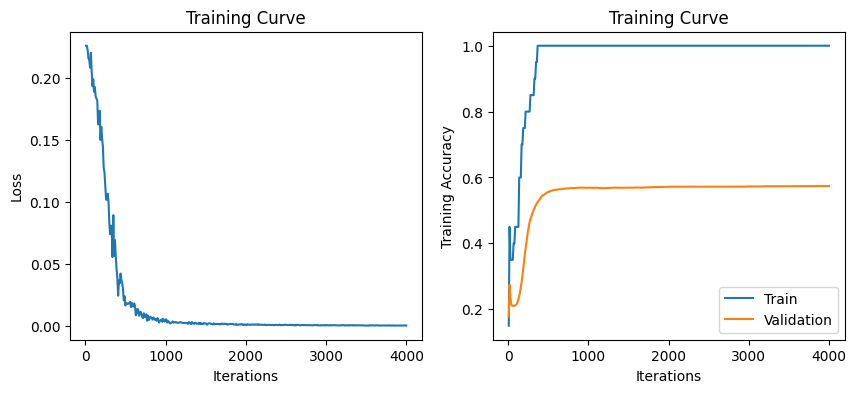

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.5739478957915831


In [72]:
set_seed(42)
model = MNISTClassifier_parametrized_3([1000,500,100]).to(device)
train(model, mnist_train, mnist_val, num_epochs=2000, with_plot=True)

In [ ]:
set_seed(42)
model = MNISTClassifier_parametrized_3([1000,500]).to(device)
train(model, mnist_train, mnist_val, num_epochs=2000, with_plot=True)

## Reprezentacje danych

In [73]:
adults_data_orig = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",header=None)

In [74]:
adults_data = adults_data_orig.copy()

In [75]:
adults_data.columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "label"]

In [76]:
adults_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,label
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [77]:
adults_data['native-country'].value_counts()

native-country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France       

In [78]:
adults_data.drop(columns=["native-country","education","workclass","relationship", "marital-status","race"],inplace=True)

In [79]:
adults_data.head()

,age,fnlwgt,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,label
0,39,77516,13,Adm-clerical,Male,2174,0,40,<=50K
1,50,83311,13,Exec-managerial,Male,0,0,13,<=50K
2,38,215646,9,Handlers-cleaners,Male,0,0,40,<=50K
3,53,234721,7,Handlers-cleaners,Male,0,0,40,<=50K
4,28,338409,13,Prof-specialty,Female,0,0,40,<=50K


In [80]:
adults_data.sex = (adults_data.sex==' Male').astype(int)
adults_data.label = (adults_data.label==' >50K').astype(int)

In [81]:
adults_data.head()

,age,fnlwgt,education-num,occupation,sex,capital-gain,capital-loss,hours-per-week,label
0,39,77516,13,Adm-clerical,1,2174,0,40,0
1,50,83311,13,Exec-managerial,1,0,0,13,0
2,38,215646,9,Handlers-cleaners,1,0,0,40,0
3,53,234721,7,Handlers-cleaners,1,0,0,40,0
4,28,338409,13,Prof-specialty,0,0,0,40,0


### Get dummies

Dane kategoryczne -> one-hot encoding

In [82]:
adults_data['occupation'].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [83]:
categorical_columns = ["occupation"]
categorical_values = pd.get_dummies(adults_data[categorical_columns]).astype(int)

categorical_values.head()

,occupation_ ?,occupation_ Adm-clerical,occupation_ Armed-Forces,occupation_ Craft-repair,occupation_ Exec-managerial,occupation_ Farming-fishing,occupation_ Handlers-cleaners,occupation_ Machine-op-inspct,occupation_ Other-service,occupation_ Priv-house-serv,occupation_ Prof-specialty,occupation_ Protective-serv,occupation_ Sales,occupation_ Tech-support,occupation_ Transport-moving
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [84]:
adults_data.drop(columns=categorical_columns,inplace=True)

In [85]:
adults_data.head()

,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,label
0,39,77516,13,1,2174,0,40,0
1,50,83311,13,1,0,0,13,0
2,38,215646,9,1,0,0,40,0
3,53,234721,7,1,0,0,40,0
4,28,338409,13,0,0,0,40,0


In [86]:
train_indices = np.random.rand(len(adults_data))>0.3

In [102]:
numerical_data = torch.from_numpy(adults_data.values[train_indices,:-1]).float()
categorical_data = torch.from_numpy(categorical_values.values[train_indices]).float()
targets = torch.from_numpy(adults_data.values[train_indices,-1]).float()

test_numerical_data = torch.from_numpy(adults_data.values[~train_indices,:-1]).float()
test_categorical_data = torch.from_numpy(categorical_values.values[~train_indices]).float()
test_targets = torch.from_numpy(adults_data.values[~train_indices,-1]).float()

In [103]:
train_dataset = data.TensorDataset(numerical_data,categorical_data,targets)
test_dataset = data.TensorDataset(test_numerical_data,test_categorical_data,test_targets)

In [89]:
train_dataset[0]

(tensor([3.9000e+01, 7.7516e+04, 1.3000e+01, 1.0000e+00, 2.1740e+03, 0.0000e+00,
         4.0000e+01]),
 tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 tensor(0.))

### Cat numerical and categorical data

In [90]:
class Adults_classifier(nn.Module):
    def __init__(self):
        super(Adults_classifier, self).__init__()
        self.layer1 = nn.Linear(adults_data.shape[1] + categorical_data.shape[1] -1, 40)
        self.act_1 = nn.LeakyReLU()
        self.d1 = nn.Dropout(0.4)
        self.layer2 = nn.Linear(40, 20)
        self.act_2 = nn.LeakyReLU()
        self.d2 = nn.Dropout(0.4)
        self.layer3 = nn.Linear(20, 1)
    def forward(self, x, cat_x):
        x = torch.cat([x,cat_x],dim=1)
        activation1 = self.act_1(self.layer1(x))
        activation1 = self.d1(activation1)
        activation2 = self.act_2(self.layer2(activation1))
        activation2 = self.d1(activation2)
        output = self.layer3(activation2)
        return output

In [91]:
def get_accuracy(model, data_loader):
    correct = 0
    total = 0
    model.eval() #*********#
    for x, cat_x, labels in data_loader:
        x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
        output = model(x, cat_x)
        pred = output>0
        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += x.shape[0]
    return correct / total

In [92]:
set_seed(42)
model = Adults_classifier().to(device)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)

iters = []
losses = []
train_acc = []
val_acc = []
for n in range(10):
    epoch_losses = []
    model.train()
    for x, cat_x, labels in iter(train_loader):
        optimizer.zero_grad()
        x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
        out = model(x, cat_x).squeeze()
        loss = criterion(out, labels)
        loss.backward()
        epoch_losses.append(loss.item())
        optimizer.step()

    loss_mean = np.array(epoch_losses).mean()
    iters.append(n)
    losses.append(loss_mean)
    test_acc = get_accuracy(model, test_loader)
    print(f"Epoch {n} loss {loss_mean:.3} test_acc: {test_acc:.3}")
    train_acc.append(get_accuracy(model, train_loader)) # compute training accuracy
    val_acc.append(test_acc)  # compute validation accuracy


print("Final Training Accuracy: {}".format(train_acc[-1]))
print("Final Validation Accuracy: {}".format(val_acc[-1]))

Epoch 0 loss 3.41e+02 test_acc: 0.762
Epoch 1 loss 26.4 test_acc: 0.765
Epoch 2 loss 17.1 test_acc: 0.766
Epoch 3 loss 11.3 test_acc: 0.766
Epoch 4 loss 7.54 test_acc: 0.766
Epoch 5 loss 4.83 test_acc: 0.768
Epoch 6 loss 3.18 test_acc: 0.765
Epoch 7 loss 1.9 test_acc: 0.769
Epoch 8 loss 1.17 test_acc: 0.767
Epoch 9 loss 0.698 test_acc: 0.765
Final Training Accuracy: 0.7638578502256693
Final Validation Accuracy: 0.7651950718685832


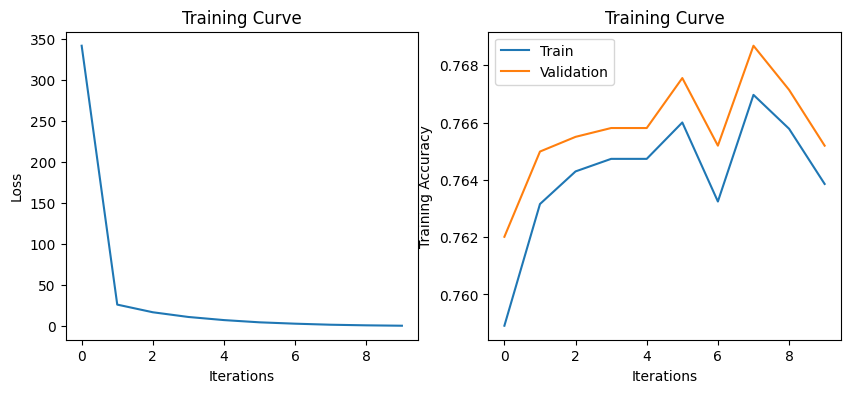

In [93]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Training Curve")
plt.plot(iters, losses, label="Train")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.title("Training Curve")
plt.plot(iters, train_acc, label="Train")
plt.plot(iters, val_acc, label="Validation")
plt.xlabel("Iterations")
plt.ylabel("Training Accuracy")
plt.legend(loc='best')
plt.show()

array([[<Axes: title={'center': 'gts'}>]], dtype=object)

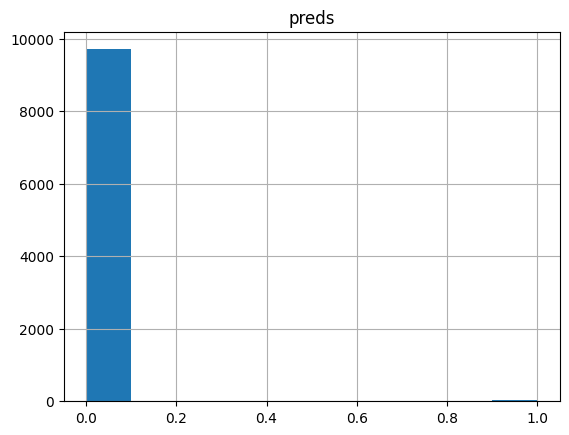

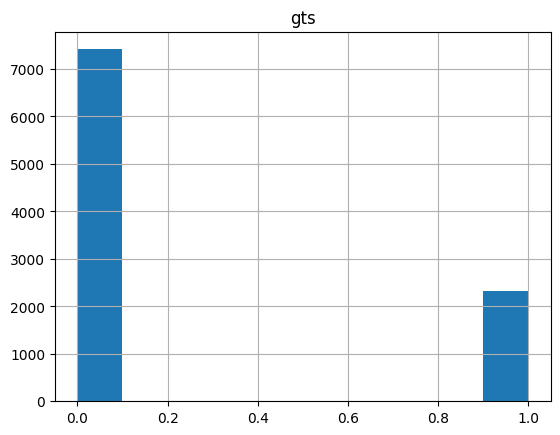

In [94]:
model.eval() #*********#
preds = []
gts = []
for x, cat_x, labels in test_loader:
    x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
    output = model(x, cat_x)
    pred = output>0
    preds.append(pred.cpu().detach().numpy())
    gts.append(labels.cpu().detach().numpy())
preds = np.concatenate(preds)
gts = np.concatenate(gts)

pd.DataFrame(preds.squeeze(), columns=["preds"]).astype(int).hist()
pd.DataFrame(gts.squeeze(), columns=["gts"]).astype(int).hist()

## Embeddings

In [95]:
class Adults_classifier_embeddings(nn.Module):
    def __init__(self):
        super(Adults_classifier_embeddings, self).__init__()
        self.emb_layer = nn.Linear(categorical_data.shape[1], categorical_data.shape[1])
        self.act_emb = nn.Tanh()
        self.layer1 = nn.Linear(adults_data.shape[1] -1 + categorical_data.shape[1], 40)
        self.act_1 =  nn.LeakyReLU()
        self.d1 = nn.Dropout(0.4)
        self.layer2 = nn.Linear(40, 20)
        self.act_2 =  nn.LeakyReLU()
        self.d2 = nn.Dropout(0.4)
        self.layer3 = nn.Linear(20, 1)
    def forward(self, x, cat_x):
        cat_x_embedded = self.emb_layer(cat_x)
        cat_x_embedded = self.act_emb(cat_x_embedded)
        x = torch.cat([x,cat_x_embedded],dim=1)
        activation1 = self.act_1(self.layer1(x))
        activation1 = self.d1(activation1)
        activation2 = self.act_2(self.layer2(activation1))
        activation2 = self.d2(activation2)
        output = self.layer3(activation2)
        return output

In [96]:
set_seed(42)
model = Adults_classifier_embeddings().to(device)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

iters = []
losses = []
train_acc = []
val_acc = []
for n in range(10):
    epoch_losses = []
    for x, cat_x, labels in iter(train_loader):
        x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
        model.train()
        out = model(x, cat_x).squeeze()

        loss = criterion(out, labels)
        loss.backward()
        epoch_losses.append(loss.item())
        optimizer.step()
        optimizer.zero_grad()

    loss_mean = np.array(epoch_losses).mean()
    iters.append(n)
    losses.append(loss_mean)
    test_acc = get_accuracy(model, test_loader)
    print(f"Epoch {n} loss {loss_mean:.3} test_acc: {test_acc:.3}")
    train_acc.append(get_accuracy(model, train_loader)) # compute training accuracy
    val_acc.append(test_acc)  # compute validation accuracy


print("Final Training Accuracy: {}".format(train_acc[-1]))
print("Final Validation Accuracy: {}".format(val_acc[-1]))

Epoch 0 loss 1.6e+02 test_acc: 0.767
Epoch 1 loss 8.78 test_acc: 0.767
Epoch 2 loss 5.48 test_acc: 0.765
Epoch 3 loss 3.35 test_acc: 0.766
Epoch 4 loss 1.88 test_acc: 0.767
Epoch 5 loss 1.24 test_acc: 0.767
Epoch 6 loss 0.81 test_acc: 0.768
Epoch 7 loss 0.662 test_acc: 0.768
Epoch 8 loss 0.605 test_acc: 0.768
Epoch 9 loss 0.586 test_acc: 0.768
Final Training Accuracy: 0.7656982603742167
Final Validation Accuracy: 0.7677618069815195


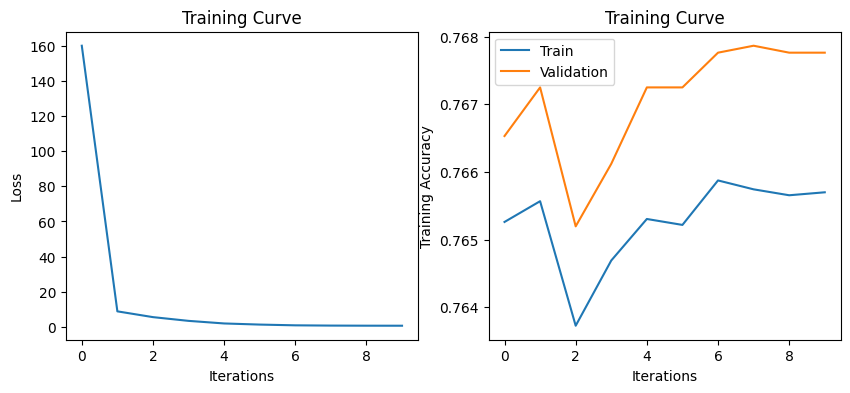

In [97]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Training Curve")
plt.plot(iters, losses, label="Train")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.title("Training Curve")
plt.plot(iters, train_acc, label="Train")
plt.plot(iters, val_acc, label="Validation")
plt.xlabel("Iterations")
plt.ylabel("Training Accuracy")
plt.legend(loc='best')
plt.show()

In [98]:
(preds<=0).sum(), (preds>0).sum()

(np.int64(9703), np.int64(37))

## Ważenie przykładów

Loss dla przykladow z rzadkich klas wymnazamy przez jakas liczbe by podkreslic istotnosc

In [104]:
(len(targets)-sum(targets))/sum(targets)

TypeError: 'Tensor' object is not callable

In [101]:
model = Adults_classifier_embeddings().to(device)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)
criterion = nn.BCEWithLogitsLoss(pos_weight=(len(targets)-sum(targets))/sum(targets))
optimizer = optim.Adam(model.parameters(), lr=1e-3)

iters = []
losses = []
train_acc = []
val_acc = []
for n in range(30):
    epoch_losses = []
    for x, cat_x, labels in iter(train_loader):
        x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
        model.train()
        out = model(x, cat_x).squeeze()

        loss = criterion(out, labels)
        loss.backward()
        epoch_losses.append(loss.item())
        optimizer.step()
        optimizer.zero_grad()

    loss_mean = np.array(epoch_losses).mean()
    iters.append(n)
    losses.append(loss_mean)
    test_acc = get_accuracy(model, test_loader)
    print(f"Epoch {n} loss {loss_mean:.3} test_acc: {test_acc:.3}")
    train_acc.append(get_accuracy(model, train_loader)) # compute training accuracy
    val_acc.append(test_acc)  # compute validation accuracy


print("Final Training Accuracy: {}".format(train_acc[-1]))
print("Final Validation Accuracy: {}".format(val_acc[-1]))

TypeError: 'Tensor' object is not callable

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Training Curve")
plt.plot(iters, losses, label="Train")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.title("Accuracy during training")
plt.plot(iters, train_acc, label="Train")
plt.plot(iters, val_acc, label="Validation")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.legend(loc='best')
plt.show()

In [ ]:
model.eval() #*********#
preds = []
gts = []
for x, cat_x, labels in test_loader:
    x, cat_x, labels = x.to(device), cat_x.to(device), labels.to(device)
    output = model(x, cat_x)
    pred = output>0
    preds.append(pred.cpu().detach().numpy())
    gts.append(labels.cpu().detach().numpy())
preds = np.concatenate(preds)
gts = np.concatenate(gts)

pd.DataFrame(preds.squeeze(), columns=["preds"]).astype(int).hist()
pd.DataFrame(gts.squeeze(), columns=["gts"]).astype(int).hist()

Bonus: https://imbalanced-learn.org/stable/index.html

![](https://www.researchgate.net/profile/Vinod-Kumar-159/publication/361949774/figure/fig2/AS:1177230768119815@1657685095263/Oversampling-and-undersampling-process.png)